# Module 09 — Capstone: *Guardian of the Grid* (student edition)

You are a dynamical-systems analyst on call for a grid operator. Generator **G4** has
been throwing erratic frequency swings, and last week a sister unit suffered an
unexplained blackout during a slow load increase. Two data logs land on your desk, and
management wants three questions answered — fast:

1. **Is G4's frequency wobble deterministic** (a controllable nonlinear instability) **or
   just random noise?**
2. **How much safety margin does a synchronized generator actually have — and what does
   "losing sync" look like in state space?**
3. **Could the sister unit's blackout have been seen coming, and where exactly is the
   point of no return?**

The physics under the hood is the **swing equation** — a single generator tied to a large
grid, mathematically a *damped, driven pendulum* (the single-machine-infinite-bus model):

$$\ddot\delta = P + A\cos(\Omega t) - \alpha\,\dot\delta - K\sin\delta.$$

This is the canonical complex-systems tipping problem, and it exercises the **whole**
`tsdynamics` toolbox: delay embedding, Lyapunov exponents and surrogate tests (Modules 04–05),
fixed points, basins and basin stability (Modules 02, 06–07), continuation, tipping points,
and early-warning signals.

**This is the scaffolded student notebook.** Every cell runs as-is, but the *analysis* is up
to you: each task gives you the narrative, a runnable starter, and a `# TODO:` marker. Fill
in the TODOs to reach the verdict. (A fully worked solution notebook exists separately —
try it yourself first!)

You will practice:
- Reconstructing a low-dimensional attractor from **one** measured channel (Takens embedding).
- Distinguishing **deterministic chaos** from stochastic noise (Lyapunov-from-data, surrogates, RQA).
- Mapping the **basin of synchrony** and quantifying safety margin (basins, basin stability, resilience).
- Detecting a tipping point from data (**critical slowing down**) and locating the fold in the model.

*Estimated time: 60–90 min.*

In [1]:
# Colab/first-run setup: install the workshop stack if tsdynamics is missing.
try:
    import tsdynamics  # noqa: F401
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "tsdynamics[viz,interactive]==5.3.1", "matplotlib", "plotly", "pandas"], check=True)
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import tsdynamics as ts
print("tsdynamics", ts.__version__)

tsdynamics 5.3.1


## The evidence on your desk

Two CSV logs live in `../capstone/data/`. Both have a multi-line `#` comment header, so
**load them with `pandas`** (`comment="#"`); `np.loadtxt`/`genfromtxt` choke on the header.

- **`scada_stream.csv`** — `t, freq_dev` (rad/s), `dt = 0.20 s`, ~4000 samples. A single
  monitored channel: generator G4's rotor **frequency deviation** during the erratic regime.
  This is *all you get* for Act I — one scalar time series.
- **`stress_test.csv`** — `t, load_P, angle, freq_dev`, `dt = 0.10 s`. The sister unit's
  log: the operator slowly ramped the load setpoint `P` from 0.55 upward under demand noise,
  and the run ends in a blackout (pole slip). This is your forensic record for Act III.

In [2]:
# Load both logs. (This cell RUNS — it is the raw evidence, no TODO.)
# Portable path setup: works from a clone (Binder/local) or standalone (Colab, where
# it fetches the model + data from GitHub so the notebook is self-sufficient).
import os
import sys
import urllib.request


def _capstone_paths():
    for cap in ("../capstone", "capstone"):
        if os.path.exists(os.path.join(cap, "grid_model.py")):
            return cap, os.path.join(cap, "data")
    base = "https://raw.githubusercontent.com/El3ssar/tsdynamics-workshop/main"
    os.makedirs("capstone/data", exist_ok=True)
    for rel in ("capstone/grid_model.py",
                "capstone/data/scada_stream.csv",
                "capstone/data/stress_test.csv"):
        if not os.path.exists(rel):
            urllib.request.urlretrieve(f"{base}/{rel}", rel)
    return "capstone", "capstone/data"


CAP, DATA = _capstone_paths()
sys.path.insert(0, CAP)
scada = pd.read_csv(f"{DATA}/scada_stream.csv", comment="#")
stress = pd.read_csv(f"{DATA}/stress_test.csv", comment="#")

t_scada = scada["t"].to_numpy()
freq = scada["freq_dev"].to_numpy()          # the single G4 channel for Act I
dt_scada = float(np.median(np.diff(t_scada)))  # ≈ 0.20 s

t_stress = stress["t"].to_numpy()
load_P = stress["load_P"].to_numpy()
angle = stress["angle"].to_numpy()
dt_stress = float(np.median(np.diff(t_stress)))  # ≈ 0.10 s

print(f"SCADA : n={len(freq)}  dt={dt_scada:.2f}s  t=[{t_scada[0]:.2f}, {t_scada[-1]:.2f}]s")
print(f"STRESS: n={len(angle)}  dt={dt_stress:.2f}s  t=[{t_stress[0]:.1f}, {t_stress[-1]:.1f}]s")
print(f"STRESS: load P ramps {load_P[0]:.3f} -> {load_P[-1]:.3f}")

SCADA : n=4000  dt=0.20s  t=[0.01, 799.81]s
STRESS: n=27230  dt=0.10s  t=[0.0, 2722.9]s
STRESS: load P ramps 0.550 -> 1.004


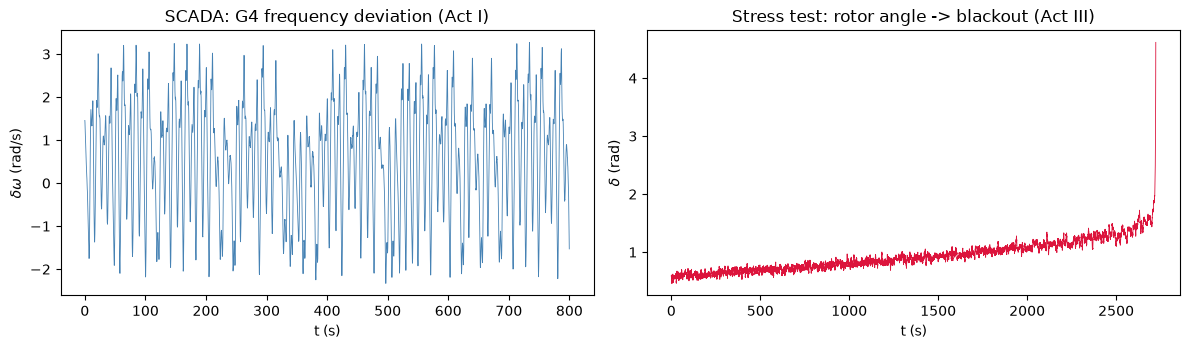

In [3]:
# Look at the raw evidence before touching any analysis. (This cell RUNS.)
fig, ax = plt.subplots(1, 2, figsize=(12, 3.6))
ax[0].plot(t_scada, freq, lw=0.6, color="steelblue")
ax[0].set(title="SCADA: G4 frequency deviation (Act I)", xlabel="t (s)", ylabel=r"$\delta\omega$ (rad/s)")
ax[1].plot(t_stress, angle, lw=0.6, color="crimson")
ax[1].set(title="Stress test: rotor angle -> blackout (Act III)", xlabel="t (s)", ylabel=r"$\delta$ (rad)")
fig.tight_layout()
plt.show()

The left panel *wobbles* — is that chaos or noise? The right panel *runs away* at the end —
that is the pole slip (blackout). Your job in the three acts below is to turn these two
pictures into a defensible engineering verdict.

---
# Act I — Diagnosis: chaos or noise?

You have **one** channel, `freq` (with `dt_scada`). If the wobble is low-dimensional
deterministic chaos, you can reconstruct the attractor by **delay embedding** (Takens 1981)
and it will show *structure*; if it is random noise it will fill space like a fuzzball. Then
you quantify: a **positive** largest Lyapunov exponent and a **surrogate test** that rejects
the linear-stochastic null clinch determinism.

### Task 1 — Reconstruct the attractor (delay embedding)

Use the embedding tools (imported for you) to find the optimal delay `tau` (mutual-information
minimum; expect ~12 samples), the Cao embedding dimension `m` (expect ~5), then build the
Takens matrix `Y = embed(freq, dimension=m, delay=tau)` and plot its first three coordinates.

*Hint:* `optimal_delay(freq)` returns a result — take `.value` and `int()` it.
`embedding_dimension(freq, delay=tau, max_dim=10)` — **always pass `delay=tau`** or it overshoots.

In [4]:
from tsdynamics.analysis.embedding import optimal_delay, embedding_dimension, embed

# Starter: find the delay (this line runs so you can see the shape of the answer).
tau = int(optimal_delay(freq).value)
print("optimal delay tau =", tau, "samples  (=", tau * dt_scada, "s)")

# TODO: estimate the Cao embedding dimension m with embedding_dimension(freq, delay=tau, max_dim=10)
#       and read off m = <result>.dimension.
m = 4  # <-- replace with the Cao estimate once you compute it

# TODO: build the Takens embedding Y = np.asarray(embed(freq, dimension=m, delay=tau))
#       then scatter/plot its first three columns (Y[:,0], Y[:,1], Y[:,2]) — does it show
#       an attractor with structure, or a fuzzball? Add a 3-D axes with fig.add_subplot(projection="3d").

optimal delay tau = 12 samples  (= 2.3999999999998636 s)


### Task 2 — Correlation dimension $D_2$

A structured attractor has a **low, non-integer** correlation dimension (Grassberger–Procaccia).
Feed your embedding `Y` to `ts.correlation_dimension` with explicit `radii` spanning the
attractor size. Expect $D_2 \approx 2.1$–$2.4$ — low ⇒ only a few active degrees of freedom.

*Hint:* pass `radii=np.logspace(-1.0, 0.8, 20)`.

In [5]:
# TODO: once you have Y from Task 1, compute
#       D2 = ts.correlation_dimension(Y, radii=np.logspace(-1.0, 0.8, 20)).value
#       and print it. Is it low (few DOF) or high (noise-like)?
radii = np.logspace(-1.0, 0.8, 20)   # decade-spanning radii for a reliable log-log fit
# D2 = ...  # TODO
print("Task 2: compute D2 from your embedding Y and interpret its magnitude.")

Task 2: compute D2 from your embedding Y and interpret its magnitude.


### Task 3 — Largest Lyapunov exponent *from data* (Kantz)

Sensitive dependence is the fingerprint of chaos: nearby trajectories diverge exponentially,
$\|\Delta\| \sim e^{\lambda_1 t}$. `lyapunov_from_data` (Kantz 1994) tracks the mean log
divergence $S(k)$ of neighbours. **You must inspect $S(k)$ first** and fit its linear region —
an unfitted `.value` is meaningless.

*Hint:* call it once with `k_max=40` and **no** `fit=`, plot `L.divergence` vs `L.times`,
then call again with `fit=(2, 10)` and read `L.value`. Expect $\lambda_1 \approx 0.08$–$0.16$/s
(a Lyapunov time of ~6–12 s).

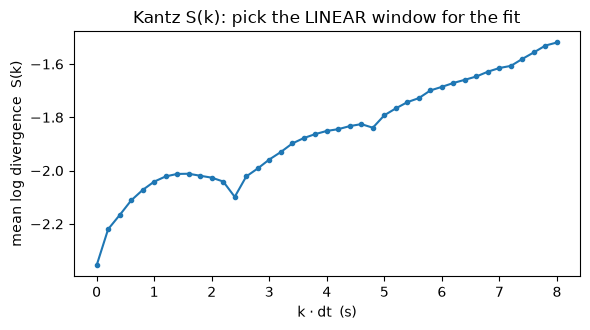

In [6]:
# Starter: compute the S(k) stretching curve (runs so you can plot it and choose the window).
L = ts.lyapunov_from_data(freq, dt=dt_scada, dimension=4, delay=tau, k_max=40, method="kantz")
S = np.asarray(L.divergence)
k_times = np.asarray(L.times)

fig, ax = plt.subplots(figsize=(6, 3.4))
ax.plot(k_times, S, "o-", ms=3)
ax.set(title="Kantz S(k): pick the LINEAR window for the fit",
       xlabel="k · dt  (s)", ylabel="mean log divergence  S(k)")
fig.tight_layout()
plt.show()

# TODO: pick (lo, hi) bracketing the straight early-growth region above (try (2, 10)),
#       then recompute with fit=(lo, hi) and read the exponent:
#   Lf = ts.lyapunov_from_data(freq, dt=dt_scada, dimension=4, delay=tau, k_max=40, method="kantz", fit=(2, 10))
#   lam1 = Lf.value  ; print("lambda1 =", lam1, "/s ; Lyapunov time =", 1/lam1, "s")

### Task 4 — Surrogate test: kill the "it's just noise" hypothesis

A positive $\lambda_1$ could be a fitting artifact of a *linear* stochastic process with the
same power spectrum. The **surrogate** method (Theiler 1992) builds phase-randomized
(IAAFT) copies that preserve the spectrum but destroy nonlinear determinism, then compares a
discriminating statistic. Use `statistic="prediction_error"` (the one that discriminates
determinism) with `method="iaaft"`. Expect a **strong rejection** (`rejected=True`, very
negative z-score).

In [7]:
# TODO: run the surrogate test and print its verdict dict.
#   st = ts.surrogate_test(freq, statistic="prediction_error", method="iaaft", n=39, seed=1)
#   print(st.to_dict())   # look for rejected=True and a large-magnitude z_score
print("Task 4: run surrogate_test on freq and check that the noise null is rejected.")

Task 4: run surrogate_test on freq and check that the noise null is rejected.


### Task 5 — Recurrence quantification (RQA)

A recurrence plot reveals deterministic structure at a glance: diagonal lines = the system
revisiting nearby states along parallel trajectories. Compute `ts.rqa(freq, recurrence_rate=0.05)`
and read the **determinism** DET (expect high, ≈0.95). Optionally image the recurrence matrix
with `ts.recurrence_matrix(freq[:600], recurrence_rate=0.05)` and `imshow` it.

In [8]:
# TODO: compute RQA and print the key metrics.
#   rq = ts.rqa(freq, recurrence_rate=0.05).to_dict()
#   print("DET =", rq["determinism"], " LAM =", rq["laminarity"])
#   Optional: rm = ts.recurrence_matrix(freq[:600], recurrence_rate=0.05); plt.imshow(np.asarray(rm.matrix), ...)
print("Task 5: quantify determinism with rqa(); high DET supports the chaos verdict.")

Task 5: quantify determinism with rqa(); high DET supports the chaos verdict.


### 📋 Act I verdict (write it up)

Combine Tasks 1–5 into one sentence. If the embedding shows structure, $D_2$ is low, $\lambda_1>0$,
the surrogate null is rejected, and DET is high, then G4's wobble is **low-dimensional
deterministic chaos** — a controllable instability of a few degrees of freedom, *not*
irreducible randomness. That means a *model* can explain and predict it. On to Act II.

---
# Act II — The model & the map of safety

The mechanism behind Act I is the swing equation. `tsdynamics` ships the model for this
capstone in `capstone/grid_model.py`; import it and work with the **actual** flow rather than
re-deriving it. The autonomous ($A=0$) machine has a **synchronized** stable node
$\delta^\* = \arcsin(P/K)$ and an **unstable saddle**; a large enough fault throws you out of
the basin of synchrony. Your job: find those fixed points, map the basin, and measure the margin.

In [9]:
# Model-import scaffold. (This cell RUNS.) The shared model lives in ../capstone/grid_model.py.
import sys
sys.path.insert(0, "../capstone")
from grid_model import GridNode, delta_star, critical_load, leading_eigenvalue  # noqa: E402
from tsdynamics.data import Box, Grid  # noqa: E402

# Sanity: the analytic operating angle and the fold load.
P0 = 0.4
print(f"Analytic synchronized angle at P={P0}: delta* = asin(P/K) = {delta_star(P0):.3f} rad")
print(f"Analytic fold (saddle-node) load    : P_c = K = {critical_load():.3f}")
# GridNode(P=..., A=..., Omega=..., alpha=..., K=...) — construct with .with_params or kwargs.
node_demo = GridNode().with_params(P=P0, A=0.0)
print("GridNode params:", node_demo.params)

Analytic synchronized angle at P=0.4: delta* = asin(P/K) = 0.412 rad
Analytic fold (saddle-node) load    : P_c = K = 1.000
GridNode params: ParamSet({P=0.4, alpha=0.2, K=1.0, A=0.0, Omega=1.0})


### Task 6 — Does the model reproduce Act I's chaos?

Put the machine in the strongly-modulated regime ($P=0.2$, $A=0.9$, $\Omega=0.6$, $\alpha=0.2$)
and confirm it is chaotic: a **positive** largest Lyapunov exponent via `lyapunov_spectrum`,
and a **stroboscopic section** at the forcing period $T = 2\pi/\Omega$ whose shape echoes the
Act I reconstruction.

*Hint:* `ts.lyapunov_spectrum(chaotic_node, final_time=300.0, dt=0.02, ic=[0.1, 0.0])`; and
`ts.StroboscopicMap(chaotic_node, period=2*np.pi/0.6).trajectory(400)` returns a section
whose `.y` you can scatter.

In [10]:
# Starter: build the modulated (chaotic-regime) node.
chaotic = GridNode().with_params(P=0.2, A=0.9, Omega=0.6, alpha=0.2)

# TODO: (a) exps = ts.lyapunov_spectrum(chaotic, final_time=300.0, dt=0.02, ic=[0.1, 0.0])
#           -> confirm exps[0] > 0 (chaos).
# TODO: (b) sm = ts.StroboscopicMap(chaotic, period=2*np.pi/0.6)
#           sec = sm.trajectory(400)
#           plt.scatter(sec.y[:,0], sec.y[:,1], s=4)  -> a strange-attractor section.
print("Task 6: confirm exps[0] > 0 and plot the stroboscopic section of the model.")

Task 6: confirm exps[0] > 0 and plot the stroboscopic section of the model.


### Task 7 — The synchronized node and the saddle (autonomous, $A=0$)

Switch off the forcing and find the equilibria of `GridNode(P=0.4, A=0)` with
`ts.fixed_points(..., region=Box(...))`. You should find a **stable** synchronized node near
$\delta^\*\approx0.41$ (complex eigenvalues ⇒ a damped spiral) and an **unstable** saddle near
$\delta\approx2.73$. Print each `fp.x`, `fp.stable`, `fp.eigenvalues`.

*Hint:* `Box(np.array([-1.6, -2.0]), np.array([1.6, 2.0]))`; iterate the returned set —
each `fp` has `.x` (location, **not** `.point`), `.stable` (bool), `.eigenvalues`.

In [11]:
# Starter: the autonomous machine and a search region.
auto = GridNode().with_params(P=0.4, A=0.0, alpha=0.2)
region = Box(np.array([-1.6, -2.0]), np.array([1.6, 2.0]))

# TODO: fps = ts.fixed_points(auto, region=region, n_seeds=80)
#       for fp in fps: print(fp.x, fp.stable, np.round(fp.eigenvalues, 3))
#       Identify the stable synchronized node and the unstable saddle.
print("Task 7: find the stable synchronized node and the unstable saddle; inspect eigenvalues.")

Task 7: find the stable synchronized node and the unstable saddle; inspect eigenvalues.


### Task 8 — Map the basin of synchrony

Not every fault recovers. Paint the **basin of attraction** of the synchronized state over a
grid of initial conditions with `ts.basins_of_attraction`. Cells that return to sync form one
basin; cells that run away (pole slip) are counted as **diverged** — that is the "blackout" set.
`imshow` the label image and report the diverged fraction.

*Hint:* `Grid(np.array([-np.pi, -3.0]), np.array([np.pi, 5.0]), (80, 80))`, `dt=0.2`,
`max_steps=400`. The result exposes `.labels` (an `(Ny, Nx)` int image),
`.diverged_fraction`, and `.attractors`.

In [12]:
# Starter: the operating node at a higher load and the IC grid. Keep the grid <= 80x80 (compute budget).
op_node = GridNode().with_params(P=0.6, A=0.0, alpha=0.2)
grid = Grid(np.array([-np.pi, -3.0]), np.array([np.pi, 5.0]), (80, 80))

# TODO: res = ts.basins_of_attraction(op_node, grid, dt=0.2, max_steps=400)
#       lab = res.labels
#       plt.imshow(lab, origin="lower", extent=[-np.pi, np.pi, -3, 5], aspect="auto")
#       print("diverged (blackout) fraction:", res.diverged_fraction)
print("Task 8: image the basin of synchrony vs the runaway/blackout set.")

Task 8: image the basin of synchrony vs the runaway/blackout set.


### Task 9 — Basin stability & resilience (the safety margin)

Two numbers management understands:
- **Basin stability** (Menck et al. 2013): the *fraction* of state space that returns to sync
  under a random fault — `ts.basin_fractions(op_node, Box(...), n=1500, dt=0.2, max_steps=400, seed=0)`.
  Expect only ~20% synchronized ⇒ a big enough fault desynchronizes.
- **Resilience** (Halekotte–Feudel 2020): the *distance* from the operating point to the basin
  edge — `ts.resilience(res, sync_id)` where `sync_id` is the synchronized attractor's label.

*Hint:* `basin_fractions(...).to_dict()` gives `{'fractions': {...}, 'diverged': ...}`.

In [13]:
# TODO: (a) bf = ts.basin_fractions(op_node, Box(np.array([-np.pi,-3.0]), np.array([np.pi,5.0])),
#                                   n=1500, dt=0.2, max_steps=400, seed=0)
#           print(bf.to_dict())  -> what fraction is synchronized?
# TODO: (b) using res from Task 8, rr = ts.resilience(res, <sync_label>) ; print(rr.value)
print("Task 9: quantify basin stability (Menck) and resilience (Halekotte-Feudel).")

Task 9: quantify basin stability (Menck) and resilience (Halekotte-Feudel).


### 📋 Act II verdict

You now have the *map of safety*: a synchronized node with a finite basin, a saddle marking its
edge, and quantitative margins (basin stability ≈ how likely a random fault recovers; resilience
≈ how far you can be pushed). But margins **shrink as load rises** — that is Act III.

---
# Act III — The warning & the verdict

Now the forensic log. The operator ramped `load_P` from 0.55 upward and the run ended in a
blackout. Two questions: **could it have been seen coming** (early-warning signals), and
**where exactly is the point of no return** (the fold)?

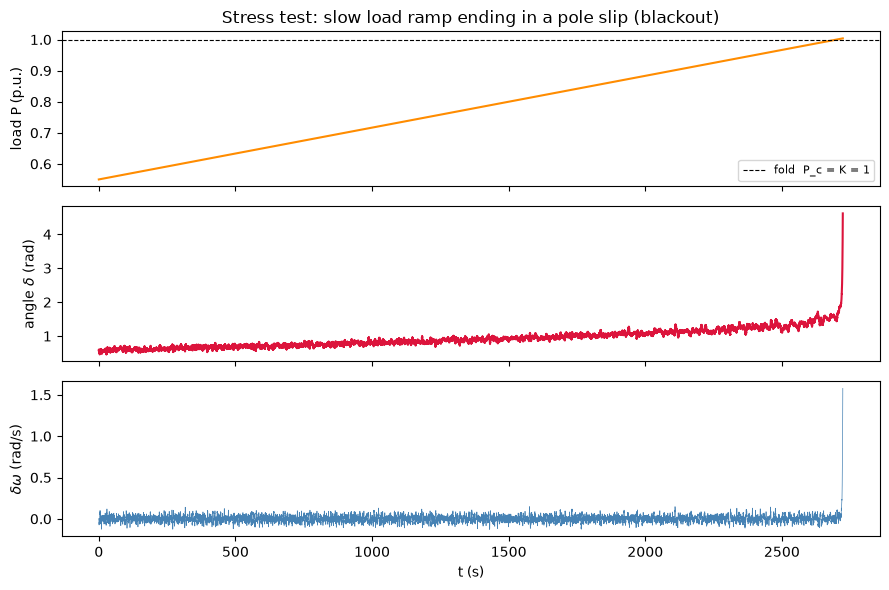

In [14]:
# Plot the stress log: load ramp, angle, and the blackout. (This cell RUNS.)
fig, ax = plt.subplots(3, 1, figsize=(9, 6), sharex=True)
ax[0].plot(t_stress, load_P, color="darkorange"); ax[0].set(ylabel="load P (p.u.)")
ax[0].axhline(critical_load(), ls="--", color="k", lw=0.8, label="fold  P_c = K = 1")
ax[0].legend(loc="lower right", fontsize=8)
ax[1].plot(t_stress, angle, color="crimson"); ax[1].set(ylabel=r"angle $\delta$ (rad)")
ax[2].plot(t_stress, stress["freq_dev"].to_numpy(), color="steelblue", lw=0.5)
ax[2].set(ylabel=r"$\delta\omega$ (rad/s)", xlabel="t (s)")
ax[0].set_title("Stress test: slow load ramp ending in a pole slip (blackout)")
fig.tight_layout()
plt.show()

### Task 10 — Early-warning signals: critical slowing down

Approaching the fold, the restoring stiffness $K\cos\delta^\*\to0$: the well flattens, recovery
slows, and fluctuations grow **more variable** and **more autocorrelated**. Detrend the angle by
its quasi-static operating point $\delta^\*(P)$ (use `delta_star(P)` from the model), then compute
a **rolling variance** and **rolling lag-1 autocorrelation** over a window (~400 samples). Both
should *rise* as $P\to1$. Mark the collapse time.

*Hint:* the residual is `resid = angle - np.array([delta_star(P) for P in load_P])` (NaN once past
the fold — mask those out). A simple rolling stat: slide a window of 400 and compute
`np.var(w)` and `np.corrcoef(w[:-1], w[1:])[0,1]`.

In [15]:
# Starter: the quasi-static detrend (runs; produces the residual to analyze).
delta_op = np.array([delta_star(P) for P in load_P])   # analytic operating angle vs load
resid = angle - delta_op                                # deviation from the moving equilibrium
valid = np.isfinite(resid)
print(f"residual defined for {valid.sum()} / {len(resid)} samples (rest are past the fold).")

W = 400  # rolling window (samples)
# TODO: compute rolling variance and rolling lag-1 autocorrelation of `resid` over window W,
#       as functions of the window-center time, then plot both vs t. Do they rise before t≈2723 s?
#   centers, rvar, rac1 = [], [], []
#   for i in range(0, valid.sum() - W, 20):
#       w = resid[valid][i:i+W]
#       centers.append(...); rvar.append(np.var(w)); rac1.append(np.corrcoef(w[:-1], w[1:])[0,1])
print("Task 10: show rolling variance AND lag-1 autocorrelation rising as P -> 1 (critical slowing).")

residual defined for 27001 / 27230 samples (rest are past the fold).
Task 10: show rolling variance AND lag-1 autocorrelation rising as P -> 1 (critical slowing).


### Task 11 — Windowed RQA as an independent EWS

Recurrence statistics also shift as the dynamics change character. Run
`ts.windowed_rqa(stress["freq_dev"].to_numpy(), window=400, step=100, recurrence_rate=0.05)`
and plot a determinism/laminarity trace vs time — a second, independent early-warning channel.

In [16]:
# TODO: wr = ts.windowed_rqa(stress["freq_dev"].to_numpy(), window=400, step=100, recurrence_rate=0.05)
#       Inspect wr (e.g. wr.to_dict() or wr.to_frame()) and plot a metric (DET/LAM) vs window time.
print("Task 11: use windowed_rqa as a second, independent early-warning channel.")

Task 11: use windowed_rqa as a second, independent early-warning channel.


### Task 12 — Why: the fold and the diverging recovery time (the mechanism)

The *mechanism* behind the rising variance is the vanishing eigenvalue of the synchronized node.
For an overdamped machine (large $\alpha$), the leading eigenvalue's magnitude $\to0$ as $P\to K$,
so recovery time $\tau_{\rm rec}=1/|{\rm Re}\,\lambda|$ **diverges**. Use `leading_eigenvalue(P, alpha)`
from the model (or `fixed_points` on `GridNode(alpha=2.5)`) to plot $\tau_{\rm rec}$ vs $P$.

*Hint:* `leading_eigenvalue(P, alpha=2.5)` returns a complex number; recovery time is
`-1 / lam.real`. Sweep `P` from 0.3 to ~0.995.

In [17]:
# TODO: for P in np.linspace(0.3, 0.995, 15):
#           lam = leading_eigenvalue(P, alpha=2.5)
#           tau_rec = -1.0 / lam.real
#       plot tau_rec vs P — it should blow up as P -> 1. This IS why the variance climbs.
Ps = np.linspace(0.3, 0.995, 15)
print("Task 12: show recovery time -1/Re(lambda) diverging as P -> K (the driver of critical slowing).")

Task 12: show recovery time -1/Re(lambda) diverging as P -> K (the driver of critical slowing).


### Task 13 — The point of no return: continuation + tipping point

Finally, locate the fold *directly* in the model. `ts.continuation` re-finds and matches the
attractors as you vary `P`; `ts.tipping_points` reads off where the synchronized attractor
**disappears** — the saddle-node fold at $P_c\approx K=1$. Then map that $P_c$ back to a **time**
in the stress log (where did `load_P` cross it?).

*Hint:*
```
cont = ts.continuation(GridNode().with_params(alpha=0.3, A=0.0), "P",
                       np.linspace(0.2, 1.15, 40),
                       Box(np.array([-np.pi, -3.0]), np.array([np.pi, 5.0])),
                       dt=0.2, max_steps=300, n=800)
tp = ts.tipping_points(cont).to_dict()   # look for kind="disappear" near P≈1.0
```

In [18]:
# TODO: run continuation over P and extract the tipping point.
#   cont = ts.continuation(GridNode().with_params(alpha=0.3, A=0.0), "P",
#                          np.linspace(0.2, 1.15, 40),
#                          Box(np.array([-np.pi, -3.0]), np.array([np.pi, 5.0])),
#                          dt=0.2, max_steps=300, n=800)
#   tp = ts.tipping_points(cont)
#   print(tp.to_dict())
# TODO: find P_c from tp, then the time it was crossed:
#   idx = int(np.argmax(load_P >= P_c)); print("crossed at t =", t_stress[idx], "s")
print("Task 13: locate the fold P_c via continuation/tipping_points and map it back to a time.")

Task 13: locate the fold P_c via continuation/tipping_points and map it back to a time.


### 🏁 Final verdict (write it up)

Assemble the case, using *your* numbers from Tasks 1–13:

1. **G4's wobble is deterministic chaos** — low $D_2$, positive $\lambda_1$, surrogate null
   rejected, high DET (Act I). It is a controllable few-DOF instability, not noise.
2. **A synchronized generator has a finite basin** and a quantifiable margin (basin stability +
   resilience, Act II); load raises risk by shrinking that margin.
3. **The blackout was foreseeable** — rolling variance and autocorrelation climbed for hundreds
   of seconds beforehand (critical slowing down), because the node's recovery time diverges as
   $P\to K$. The fold sits at $P_c = K = 1$, and the operator crossed it (Act III).

**Recommendation:** keep load a safe margin below $P_c$, watch the rolling variance as a live
alarm, and (stretch) show that raising the grid coupling $K$ or the damping $\alpha$ pushes the
fold out — buying margin. You have just used delay embedding, Lyapunov exponents, surrogates,
RQA, fixed points, basins, basin stability, resilience, continuation, and tipping-point analysis
on **one** coherent problem. That is the whole toolbox.

## Where next

- Compare your worked answers against the fully-solved **solution notebook** for this capstone.
- **Stretch goals:** repeat the basin/tipping analysis with the *stochastic* `NoisyGridNode`
  (also in `grid_model.py`) to see how demand noise moves the effective margin; and rerun the
  continuation with larger $K$ or $\alpha$ to watch the fold shift.
- Save your two hero figures — the **basin of synchrony** and the **rising-variance EWS** — for
  the operator's report.